# GNN for Graph Level Predictions about Knots (Volume)

Juan José H. Beltrán

In [1]:
# Requirements:
# !pip install numpy pandas scikit-learn torch torch_geometric matplotlib

In [2]:
import dataset
import torch
import numpy as np
import random
from torch_geometric.loader import DataLoader
from settings import *

### Asegurar Reproduciilidad

In [3]:
# Define the seed value
seed = 31

# Set seed for PyTorch
torch.manual_seed(seed)

# Set seed for CUDA (if using GPUs)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)  # For multi-GPU setups

# Set seed for Python's random module
random.seed(seed)

# Set seed for NumPy
np.random.seed(seed)

# Ensure deterministic behavior for PyTorch operations
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Create Dataset and Dataloader

In [4]:
train_loader, val_loader, deg, knot_dataset = dataset.load()

# Esto debería pasarse a dataset.py
testGeneralisazion = DataLoader(dataset.fetchDataset("datasets/linkDataset.csv")["dataPoint"], batch_size = BATCH_SIZE)

Dataset consists of  2381 train samples and  596 test samples
max_degree: 11


### Explore Dataset

Cada dataset contiene una fila por cada grafo. Cada grafo tiene a su vez:
- `x`: Tensor con las features de los nodos. En este caso contiene el grado del nodo (input features: 1).
- `edge_index`: Tensor con la descripción de las aristas del grafo, especificando su origen y destino.
- `edge_atrr`: Tensor con los atributos de cada arista del grafo. En este caso son la "distancia" y si está o no "alternando".
- `y`: Tensor con los labels. En este caso, es un único label para todo el grafo: el invariante a predecir.

In [5]:
knot_dataset = knot_dataset.dataPoint

In [6]:
knot_dataset[0].edge_attr

tensor([[0.1294, 1.0000],
        [0.0452, 1.0000],
        [0.0452, 1.0000],
        [0.0452, 1.0000],
        [0.0452, 1.0000],
        [0.0452, 1.0000],
        [0.0452, 1.0000],
        [0.0452, 1.0000],
        [0.1294, 1.0000],
        [0.0452, 1.0000],
        [0.0452, 1.0000],
        [0.0452, 1.0000],
        [0.1294, 1.0000],
        [0.1294, 1.0000],
        [0.1294, 1.0000],
        [0.1294, 1.0000]])

## Functions and Classes for GNN

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.optim.lr_scheduler import ReduceLROnPlateau
from settings import *

In [8]:
# Import custom GNN models from models.py
from models import PNAKnotNet
from models import GATKnotNet
from models import TransKnotNet

In [9]:
torch.manual_seed(31)
model = PNAKnotNet(deg)

optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
scheduler = ReduceLROnPlateau(optimizer, mode = 'min', factor = 0.5, patience = 20, min_lr = 0.00001)

In [10]:
def train(epoch):
    model.train()

    total_loss = 0
    for data in train_loader:
        optimizer.zero_grad()
        if ADDITIONAL:
            out = model(data.x, data.edge_index, data.edge_attr, data.batch, data.featureEncoding)
        else:
            if USE_DISTANCE_ATTRIBUTE:
                out = model(data.x, data.edge_index, data.edge_attr, data.batch)
            else:
                out = model(data.x, data.edge_index, data.edge_attr.reshape(-1, 1), data.batch)

        if LOSS == "abs":
            loss = (out.squeeze() - data.y).abs().mean() # Mean Absolute Error
        elif LOSS == "squared":
            loss = (out.squeeze() - data.y).square().mean() # Mean Squared Error

        loss.backward()
        total_loss += loss.item() * data.num_graphs
        optimizer.step()

    return total_loss / len(train_loader.dataset)

In [11]:
@torch.no_grad()
def test(loader):
    model.eval()

    total_error = 0
    for data in loader:
        if ADDITIONAL:
            out = model(data.x, data.edge_index, data.edge_attr, data.batch, data.featureEncoding)
        else:
            if USE_DISTANCE_ATTRIBUTE:
                out = model(data.x, data.edge_index, data.edge_attr, data.batch)
            else:
                out = model(data.x, data.edge_index, data.edge_attr.reshape(-1, 1), data.batch)
        
        if LOSS=="abs":
            total_error += (out.squeeze() - data.y).abs().sum().item()
        elif LOSS=="squared":
            total_error += (out.squeeze() - data.y).square().sum().item()
    
    return total_error / len(loader.dataset)

## Train Model

In [12]:
try_generalization = True

history_train_loss = []
history_val_loss = []
history_gen_loss = []
history_gen_acc = []

for epoch in range(1, 250):
    val_loss = test(val_loader)
    if try_generalization:
        gen_loss = test(testGeneralisazion)
    loss = train(epoch)

    # Append history for plotting later
    history_train_loss.append(loss)
    history_val_loss.append(val_loss)
    if try_generalization:
        history_gen_loss.append(gen_loss)

    scheduler.step(loss)
    if try_generalization:
        print(f'Epoch: {epoch:02d}, Train loss: {loss:.4f}, Val loss: {val_loss:.4f}, Generalization loss: {gen_loss:.4f}')
    else:
        print(f'Epoch: {epoch:02d}, Train loss: {loss:.4f}, Val loss: {val_loss:.4f}')

Epoch: 01, Train loss: 233.6751, Val loss: 237.0839, Generalization loss: 33.6146
Epoch: 02, Train loss: 220.3558, Val loss: 228.0115, Generalization loss: 30.5394
Epoch: 03, Train loss: 198.9583, Val loss: 209.0808, Generalization loss: 25.5287
Epoch: 04, Train loss: 170.3250, Val loss: 183.5082, Generalization loss: 18.7708
Epoch: 05, Train loss: 137.4600, Val loss: 152.1434, Generalization loss: 10.3214
Epoch: 06, Train loss: 103.4223, Val loss: 118.0217, Generalization loss: 4.6676
Epoch: 07, Train loss: 72.3597, Val loss: 85.2203, Generalization loss: 2.8156
Epoch: 08, Train loss: 47.9601, Val loss: 57.4862, Generalization loss: 7.9750
Epoch: 09, Train loss: 31.3175, Val loss: 37.8960, Generalization loss: 17.0597
Epoch: 10, Train loss: 20.9918, Val loss: 25.1653, Generalization loss: 35.9715
Epoch: 11, Train loss: 15.4191, Val loss: 17.7006, Generalization loss: 56.8788
Epoch: 12, Train loss: 12.6508, Val loss: 13.6649, Generalization loss: 72.1776
Epoch: 13, Train loss: 11.5719,

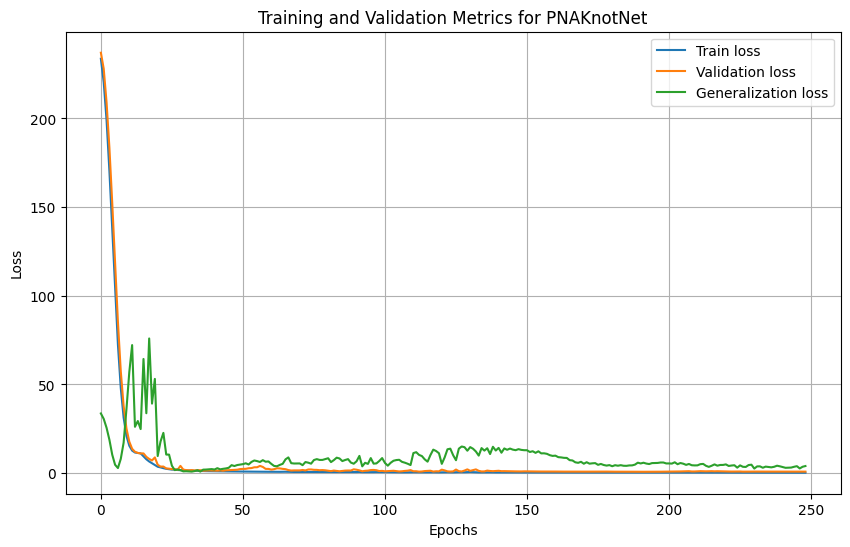

In [13]:
# Show graphs of loss and accuracy
plt.figure(figsize=(10, 6))
plt.grid()
plt.plot(history_train_loss, label = "Train loss")
plt.plot(history_val_loss, label = "Validation loss")
if try_generalization:
    plt.plot(history_gen_loss, label = "Generalization loss")

plt.title(f"Training and Validation Metrics for {model._get_name()}")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

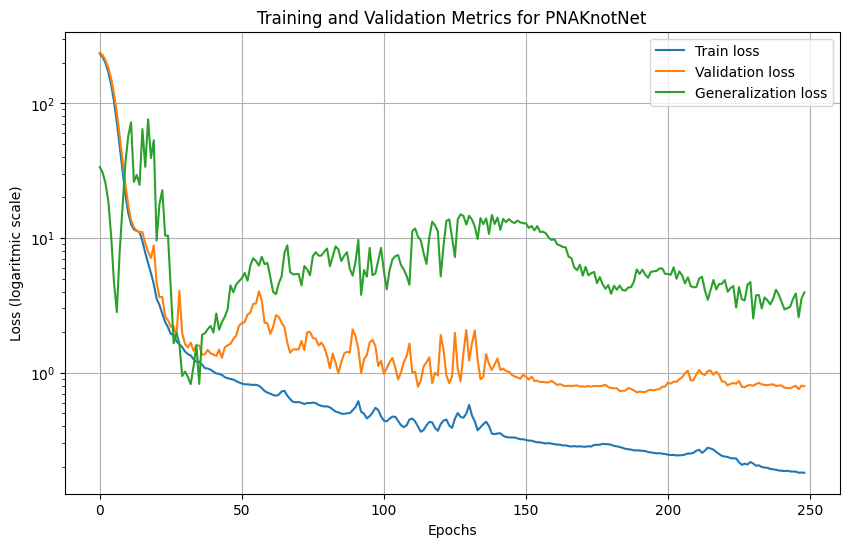

In [14]:
# Show graphs of loss and accuracy
plt.figure(figsize=(10, 6))
plt.grid()
plt.plot(history_train_loss, label = "Train loss")
plt.plot(history_val_loss, label = "Validation loss")
if try_generalization:
    plt.plot(history_gen_loss, label = "Generalization loss")

plt.title(f"Training and Validation Metrics for {model._get_name()}")
plt.xlabel("Epochs")
plt.ylabel("Loss (logaritmic scale)")
plt.yscale("log")
plt.legend()
plt.show()

In [15]:
# Save the trained model
torch.save(model.state_dict(), f"models/{model._get_name()}_{FEATURE}_{LOSS}_bs{BATCH_SIZE}_add{ADDITIONAL}_distance{USE_DISTANCE_ATTRIBUTE}.pt")

In [16]:
model

PNAKnotNet(
  (convs): ModuleList(
    (0): PNAConv(1, 20, towers=4, edge_dim=-1)
    (1): PNAConv(20, 20, towers=4, edge_dim=-1)
  )
  (batch_norms): ModuleList(
    (0-1): 2 x BatchNorm(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (mlp): Sequential(
    (0): Linear(in_features=60, out_features=25, bias=True)
    (1): BatchNorm(25, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Tanh()
    (3): Linear(in_features=25, out_features=25, bias=True)
    (4): Tanh()
    (5): Linear(in_features=25, out_features=25, bias=True)
    (6): Tanh()
    (7): Linear(in_features=25, out_features=25, bias=True)
    (8): ReLU()
    (9): Linear(in_features=25, out_features=1, bias=True)
  )
)